### DIABETES
#### About Dataset
The Diabetes prediction dataset is a collection of medical and demographic data from patients, along with their diabetes status (positive or negative). The data includes features such as age, gender, body mass index (BMI), hypertension, heart disease, smoking history, HbA1c level, and blood glucose level. This dataset can be used to build machine learning models to predict diabetes in patients based on their medical history and demographic information. This can be useful for healthcare professionals in identifying patients who may be at risk of developing diabetes and in developing personalized treatment plans. Additionally, the dataset can be used by researchers to explore the relationships between various medical and demographic factors and the likelihood of developing diabetes.

- **Pregnancies:** Number of times pregnant
- **Glucose:** Plasma glucose concentration a 2 hours in an oral glucose tolerance test
- **BloodPressure:** Diastolic blood pressure (mm Hg)
- **SkinThickness:** Triceps skin fold thickness (mm)
- **Insulin:** 2-Hour serum insulin (mu U/ml)
- **BMI:** Body mass index (weight in kg/(height in m)^2)
- **DiabetesPedigreeFunction:** Diabetes pedigree function
- **Age:** Age (years)
- **Outcome:** Class variable (0 or 1)

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, classification_report, RocCurveDisplay
from sklearn.model_selection import train_test_split, cross_validate

In [49]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x : '%.3f' % x)
pd.set_option('display.width', 500)

In [50]:
df = pd.read_csv("/Users/etmco/Downloads/Kurs_Materyalleri_ML/datasets/diabetes.csv")

In [51]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


In [52]:
df.shape

(768, 9)

In [53]:
outcome_count = df.groupby(['Outcome']).agg({'Outcome': 'count'})

In [54]:
outcome_percentage = (outcome_count / df.shape[0]) * 100

In [55]:
outcome_percentage
# dengesiz veriseti

,Outcome
Outcome,
0,65.104
1,34.896


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose,768.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000
BloodPressure,768.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000
SkinThickness,768.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000
Insulin,768.000,79.799,115.244,0.000,0.000,30.500,127.250,846.000
BMI,768.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome,768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000


In [58]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

#### EDA

In [59]:
def minmax(df, *cols):
    for col in cols:
        max_value = df[col].max()
        min_value = df[col].min()
        print(f'{col} Max ..: {max_value}')
        print(f'{col} Min ..: {min_value}')
        print('-'*25)

In [60]:
minmax(df, "Glucose", "BloodPressure", "SkinThickness", "BMI", "Age", "Insulin")

Glucose Max ..: 199
Glucose Min ..: 0
-------------------------
BloodPressure Max ..: 122
BloodPressure Min ..: 0
-------------------------
SkinThickness Max ..: 99
SkinThickness Min ..: 0
-------------------------
BMI Max ..: 67.1
BMI Min ..: 0.0
-------------------------
Age Max ..: 81
Age Min ..: 21
-------------------------
Insulin Max ..: 846
Insulin Min ..: 0
-------------------------


#### Threshold analyze:

In [61]:
def thresholds(df, col_name : str, q1 : float, q3 :float):
    #quantile definition:
    quantile1 = df[col_name].quantile(q1)
    quantile3 = df[col_name].quantile(q3)

    #iqr colculation:
    iqr = quantile3 - quantile1

    upper_l = quantile3 + (1.5 * iqr)
    lower_l = quantile1 - (1.5 * iqr)

    ## Boxplot:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data = df[col_name])

    # Adding the threshold values to the graph (Opsiyonel ama çok açıklayıcıdır)
    plt.axhline(y=upper_l, color='r', linestyle='--', label='Üst Eşik')
    plt.axhline(y=lower_l, color='r', linestyle='--', label='Alt Eşik')

    plt.title(f"{col_name} için Aykırı Değer Analizi")
    #plt.legend()
    plt.show()

    return upper_l.item(), lower_l.item()

    
    

In [62]:
class outlier_detection:

    
    def __init__(self, df):
        self.df = df.copy()
    
    def thresholds(self, col_name: str, q1: float = 0.25, q3: float = 0.75):
        quantile1 = self.df[col_name].quantile(q1)
        quantile3 = self.df[col_name].quantile(q3)
        iqr = quantile3 - quantile1
        upper_l = quantile3 + (1.5 * iqr)
        lower_l = quantile1 - (1.5 * iqr)
    
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=self.df[col_name])
        plt.axhline(y=upper_l, color='r', linestyle='--', label='Üst Eşik')
        plt.axhline(y=lower_l, color='r', linestyle='--', label='Alt Eşik')
        plt.title(f"{col_name} için Aykırı Değer Analizi")
        plt.legend()
        plt.show()
    
        return float(upper_l), float(lower_l)

        
    def thresholds_numeric(self, col_name: str, q1: float = 0.25, q3: float = 0.75):
        quantile1 = self.df[col_name].quantile(q1)
        quantile3 = self.df[col_name].quantile(q3)
        iqr = quantile3 - quantile1
        upper_l = quantile3 + (1.5 * iqr)
        lower_l = quantile1 - (1.5 * iqr)
    
        return float(upper_l), float(lower_l)

    def check_if_outlier(self, col_list, q1 = 0.25, q3 = 0.75):
        #upper_l, lower_l = thresholds_numeric(df, col, q1, q3)
        for col in col_list:
            upper_l, lower_l = self.thresholds_numeric(col, q1, q3)
            upper_limit = self.df[col][self.df[col] > upper_l].shape[0]
            lower_limit =  self.df[col][self.df[col] < lower_l].shape[0]

            print(f"{col} upper bound..: {round(upper_limit,4)}")
            print(f"{col} lower bound..: {round(lower_limit,4)}")
            print('-'*50)
    

In [63]:
od = outlier_detection(df)

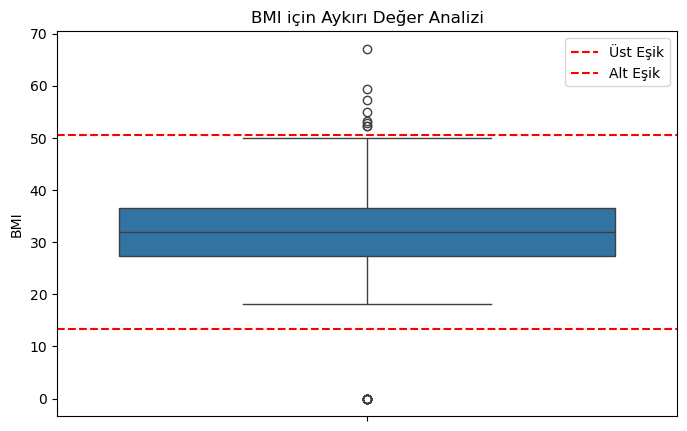

Upper Limit..: 50.550000000000004
Lower_Limit..: 13.35


In [64]:
upper_limit, lower_limit = od.thresholds(col_name ="BMI", q1 = 0.25, q3 = 0.75)
print(f'Upper Limit..: {upper_limit}\nLower_Limit..: {lower_limit}')

In [65]:
df['Glucose'][df['Glucose'] > upper_limit].count().item()

762

In [66]:
def catch_num(df):
    num_cols = []
    for col in df.columns:
        if df[col].dtype in [int, float] and col != 'Outcome':
            num_cols.append(col)
    return num_cols

In [67]:
col_list = catch_num(df)
col_list

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [68]:
od.check_if_outlier(col_list)

Pregnancies upper bound..: 4
Pregnancies lower bound..: 0
--------------------------------------------------
Glucose upper bound..: 0
Glucose lower bound..: 5
--------------------------------------------------
BloodPressure upper bound..: 7
BloodPressure lower bound..: 38
--------------------------------------------------
SkinThickness upper bound..: 1
SkinThickness lower bound..: 0
--------------------------------------------------
Insulin upper bound..: 34
Insulin lower bound..: 0
--------------------------------------------------
BMI upper bound..: 8
BMI lower bound..: 11
--------------------------------------------------
DiabetesPedigreeFunction upper bound..: 29
DiabetesPedigreeFunction lower bound..: 0
--------------------------------------------------
Age upper bound..: 9
Age lower bound..: 0
--------------------------------------------------


In [69]:
def visualize_num_cols(df, col_list: list, size: tuple, n: int, m: int, bins: int):
    fig = plt.figure(figsize = size)
    gs = fig.add_gridspec(n, m)
    for idx, col in enumerate(col_list):
        row = idx // m
        col_pos = idx % m
        
        ax1 = fig.add_subplot(gs[row, col_pos])
        ax1.hist(df[col], bins = bins)
        ax1.set_title(f"Distribution of the {col}")
    plt.tight_layout()
    plt.show()


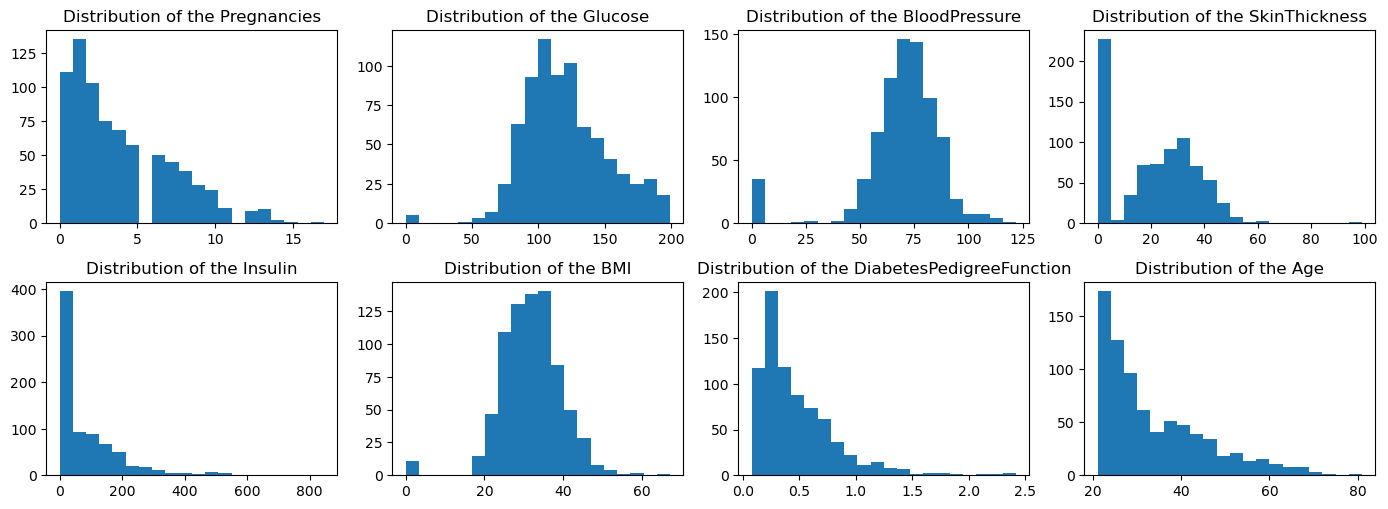

In [70]:
visualize_num_cols(df,col_list, (14,10), n = 4, m = 4, bins = 20)

In [71]:
def targetvsfeatures(df, col_list, target_col):
    col_means = {}
    for col in col_list:
        col_means[col] = df.groupby(target_col)[col].mean()
    return pd.DataFrame(col_means).T
        

In [72]:
means_df = targetvsfeatures(df, col_list, 'Outcome')

In [73]:
means_df

Outcome,0,1
Pregnancies,3.298,4.866
Glucose,109.980,141.257
BloodPressure,68.184,70.825
SkinThickness,19.664,22.164
Insulin,68.792,100.336
BMI,30.304,35.143
DiabetesPedigreeFunction,0.430,0.550
Age,31.190,37.067


In [74]:
def robust_(df, col_list):
    for col in col_list:
        df[col] = RobustScaler().fit_transform(df[[col]])
    return df.head()

In [75]:
robust_(df,col_list)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.600,0.752,0.000,0.375,-0.240,0.172,0.665,1.235,1
1,-0.400,-0.776,-0.333,0.188,-0.240,-0.581,-0.056,0.118,0
2,1.000,1.600,-0.444,-0.719,-0.240,-0.935,0.783,0.176,1
3,-0.400,-0.679,-0.333,0.000,0.499,-0.419,-0.537,-0.471,0
4,-0.600,0.485,-1.778,0.375,1.081,1.194,5.008,0.235,1


#### Model Precidtion

In [76]:
X = df.iloc[:,0:7]
y = df.iloc[:,-1]

In [77]:
log_reg = LogisticRegression().fit(X,y)

In [78]:
log_reg.intercept_

array([-1.1838642])

In [79]:
log_reg.coef_

array([[ 0.72499045,  1.46523861, -0.20447098, -0.01469653, -0.15191615,
         0.8019029 ,  0.36340242]])

In [80]:
print(f"Model...: {log_reg.intercept_} + {log_reg.coef_[0][0].item()} x {X.columns[0]} + {log_reg.coef_[0][1].item()} x {X.columns[1]} + {log_reg.coef_[0][2].item()} x {X.columns[2]} + {log_reg.coef_[0][3].item()} x {X.columns[3]} + {log_reg.coef_[0][4].item()} x {X.columns[4]} + {log_reg.coef_[0][5].item()} x {X.columns[5]} + {log_reg.coef_[0][6].item()} x {X.columns[6]}")

Model...: [-1.1838642] + 0.7249904498220353 x Pregnancies + 1.4652386105694042 x Glucose + -0.20447097833998945 x BloodPressure + -0.014696525583437436 x SkinThickness + -0.1519161528596595 x Insulin + 0.8019028983779596 x BMI + 0.3634024214187697 x DiabetesPedigreeFunction


In [81]:
y_pred = log_reg.predict(X)

In [82]:
y_pred[0:10]

array([1, 0, 1, 0, 1, 0, 0, 1, 1, 0])

In [83]:
y[0:10]

0    1
1    0
2    1
3    0
4    1
5    0
6    1
7    0
8    1
9    1
Name: Outcome, dtype: int64

#### Model Evaluation

In [84]:
def plot_confusion_matrix(y, y_pred):
    acc = round(accuracy_score(y, y_pred), 2)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot = True, fmt = '.0f')
    plt.xlabel('y_pred')
    plt.ylabel('y')
    plt.title('Accuracy Score {0}'.format(acc), size = 10)
    plt.show()

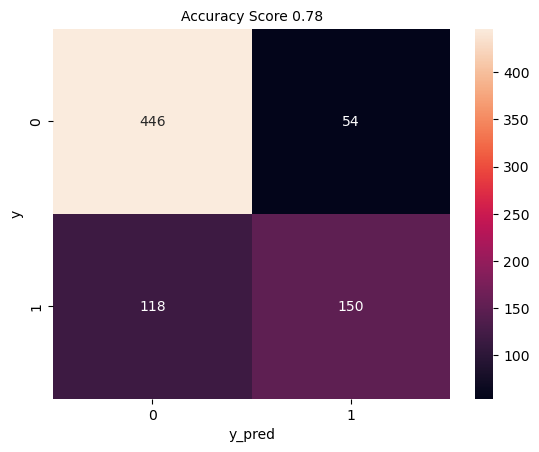

In [85]:
plot_confusion_matrix(y, y_pred)

In [86]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       500
           1       0.74      0.56      0.64       268

    accuracy                           0.78       768
   macro avg       0.76      0.73      0.74       768
weighted avg       0.77      0.78      0.77       768



In [87]:
y_prob = log_reg.predict_proba(X)[:, 1]

In [89]:
roc_auc_score(y, y_prob)

0.838402985074627

#### Model Validation :

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 17)

In [91]:
print(f'X Train shape...: {X_train.shape}')
print(f'X Test shape...: {X_test.shape}')
print(f'y Train shape...: {y_train.shape}')
print(f'y test shape...: {y_test.shape}')

X Train shape...: (614, 7)
X Test shape...: (154, 7)
y Train shape...: (614,)
y test shape...: (154,)


In [92]:
log_model = LogisticRegression().fit(X_train, y_train)

In [93]:
log_model.intercept_

array([-1.22508356])

In [94]:
log_model.coef_

array([[ 0.74352466,  1.39038681, -0.15100443, -0.10914755, -0.15366996,
         0.69857124,  0.43862321]])

In [95]:
print(f"Model...: {log_reg.intercept_} + {log_reg.coef_[0][0].item()} x {X.columns[0]} + {log_reg.coef_[0][1].item()} x {X.columns[1]} + {log_reg.coef_[0][2].item()} x {X.columns[2]} + {log_reg.coef_[0][3].item()} x {X.columns[3]} + {log_reg.coef_[0][4].item()} x {X.columns[4]} + {log_reg.coef_[0][5].item()} x {X.columns[5]} + {log_reg.coef_[0][6].item()} x {X.columns[6]}")

Model...: [-1.1838642] + 0.7249904498220353 x Pregnancies + 1.4652386105694042 x Glucose + -0.20447097833998945 x BloodPressure + -0.014696525583437436 x SkinThickness + -0.1519161528596595 x Insulin + 0.8019028983779596 x BMI + 0.3634024214187697 x DiabetesPedigreeFunction


In [96]:
y_pred = log_model.predict(X_test)

In [97]:
y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 1, 1, 1])

In [98]:
y_prob = log_model.predict_proba(X_test)[:, 1]

In [99]:
#y_prob.shape
y_test.shape

(154,)

In [100]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.92      0.84        97
           1       0.79      0.53      0.63        57

    accuracy                           0.77       154
   macro avg       0.78      0.72      0.73       154
weighted avg       0.78      0.77      0.76       154



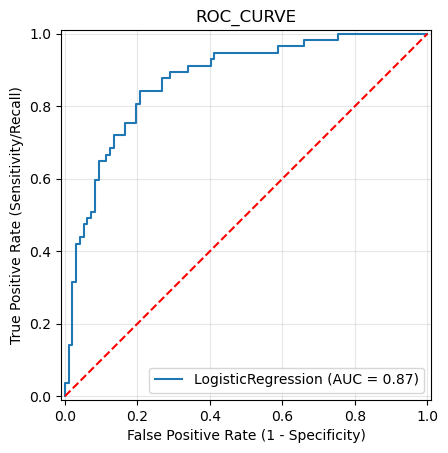

In [101]:
RocCurveDisplay.from_estimator(log_model, X_test, y_test)
plt.title('ROC_CURVE')
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()

In [103]:
roc_auc_score(y_test, y_prob)

0.8730330982094412

### K Fold Cross Validation :

In [104]:
X_c = df.drop(['Outcome'], axis = 1)
y_c = df['Outcome']

In [106]:
cv_results = cross_validate(log_model, X, y, cv = 5, scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [107]:
cv_results['test_accuracy']
# burada 5 kat yağtığımız için 5 adet accuracy değeri olacaktır. Bunların ortalamalarını alarak accuracy i buluruz.

array([0.75974026, 0.75974026, 0.75974026, 0.81699346, 0.77124183])

In [112]:
print(f'ortalama test accuracy...:{round(cv_results["test_accuracy"].mean().item(),4)}')

ortalama test accuracy...:0.7735


In [114]:
print(f'ortalama test precision...:{round(cv_results["test_precision"].mean().item(),4)}')

ortalama test precision...:0.7291


In [115]:
print(f'ortalama test recall...:{round(cv_results["test_recall"].mean().item(),4)}')

ortalama test recall...:0.5635


In [116]:
print(f'ortalama test f1 Score...:{round(cv_results["test_f1"].mean().item(),4)}')

ortalama test f1 Score...:0.6338


In [117]:
print(f'ortalama test roc_auc...:{round(cv_results["test_roc_auc"].mean().item(),4)}')

ortalama test roc_auc...:0.8335
